# Figuras metodológicas para el TFM

Este notebook genera y guarda las figuras del capítulo de **Metodología**.

Ubicación recomendada del notebook:

```text
/data/users/kabasmen/MethaneProjectTFM/Notebooks/Build_Methodology_Figures_TFM.ipynb
```

Carpeta de salida de las figuras:

```text
/data/users/kabasmen/MethaneProjectTFM/Docs/MethodologyFig
```

Figuras generadas:

1. `Figure_Methodology_Pipeline.png`
2. `Figure_ProjectStructure.png`
3. `Figure_ConfigB_ConfigC_Channels.png`
4. `Figure_ModelFamilies.png`
5. `Figure_EvaluationWorkflow.png`
6. `Figure_PredictionPanelLayout.png`

También se guardan versiones `.pdf` si `SAVE_PDF = True`.


In [1]:
from pathlib import Path
import textwrap
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
from IPython.display import display, Image

# ============================================================
# RUTAS DEL REPOSITORIO
# ============================================================

PROJECT_ROOT = Path("/data/users/kabasmen/MethaneProjectTFM")
NOTEBOOK_DIR = PROJECT_ROOT / "Notebooks"
OUTDIR = PROJECT_ROOT / "Docs" / "MethodologyFig"

NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
OUTDIR.mkdir(parents=True, exist_ok=True)

DPI = 220
SAVE_PDF = True

# ============================================================
# PALETA Y ESTILO
# ============================================================

NAVY = "#153E8A"
BLUE = "#2F7ED8"
MID_BLUE = "#4E9AE6"
LIGHT_BLUE = "#D9ECFF"
PALE_BLUE = "#EEF6FF"
DARK = "#1E2A39"
GRAY = "#6E7B8B"
LIGHT_GRAY = "#E6ECF2"
GREEN = "#35B095"
ORANGE = "#F39C12"
CYAN = "#12CFE3"
RED = "#E74C3C"
YELLOW = "#F1C40F"
PURPLE = "#6C5CE7"
WHITE = "#FFFFFF"
BLACK = "#000000"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

print("PROJECT_ROOT:", PROJECT_ROOT)
print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("OUTDIR:", OUTDIR)
print("OUTDIR exists:", OUTDIR.exists())

PROJECT_ROOT: /data/users/kabasmen/MethaneProjectTFM
NOTEBOOK_DIR: /data/users/kabasmen/MethaneProjectTFM/Notebooks
OUTDIR: /data/users/kabasmen/MethaneProjectTFM/Docs/MethodologyFig
OUTDIR exists: True


In [2]:
# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def save_figure(fig, name):
    """Guarda la figura en PNG y, opcionalmente, PDF."""
    png_path = OUTDIR / f"{name}.png"
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight", facecolor="white")
    if SAVE_PDF:
        pdf_path = OUTDIR / f"{name}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"[OK] Guardado: {png_path}")
    return png_path

def show_saved(path):
    """Muestra una figura guardada dentro del notebook."""
    display(Image(filename=str(path)))

def add_round_box(ax, xy, w, h, text, fc=BLUE, ec=None, lw=1.8,
                  text_color=WHITE, fontsize=13, weight="bold",
                  radius=0.04, align="center", subtitle=None, subtitle_size=10):
    if ec is None:
        ec = fc

    box = FancyBboxPatch(
        xy, w, h,
        boxstyle=f"round,pad=0.012,rounding_size={radius}",
        linewidth=lw, edgecolor=ec, facecolor=fc
    )
    ax.add_patch(box)

    x, y = xy
    if subtitle is None:
        ax.text(
            x + w/2, y + h/2, text,
            ha=align, va="center", color=text_color,
            fontsize=fontsize, fontweight=weight
        )
    else:
        ax.text(
            x + w/2, y + h*0.62, text,
            ha="center", va="center", color=text_color,
            fontsize=fontsize, fontweight=weight
        )
        ax.text(
            x + w/2, y + h*0.33, subtitle,
            ha="center", va="center", color=text_color,
            fontsize=subtitle_size
        )

def add_arrow(ax, p1, p2, color=BLUE, lw=2.5, rad=0.0, arrowstyle='-|>'):
    arrow = FancyArrowPatch(
        p1, p2,
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle=arrowstyle,
        mutation_scale=18,
        lw=lw, color=color
    )
    ax.add_patch(arrow)

def add_title(ax, title, subtitle=None):
    ax.text(0.5, 0.98, title, ha="center", va="top",
            fontsize=18, fontweight="bold", color=DARK,
            transform=ax.transAxes)
    if subtitle:
        ax.text(0.5, 0.94, subtitle, ha="center", va="top",
                fontsize=11, color=GRAY, transform=ax.transAxes)

def add_section_label(ax, x, y, text, color=NAVY):
    ax.text(x, y, text, ha="left", va="center",
            fontsize=13, fontweight="bold", color=color)

def wrap(txt, n):
    return "\n".join(textwrap.wrap(txt, width=n))

## Figura 1. Flujo metodológico general

Resume la secuencia completa del trabajo: índice TACO, exploración, filtros, features, tensores, entrenamiento, evaluación, análisis visual y comparación final.


[OK] Guardado: /data/users/kabasmen/MethaneProjectTFM/Docs/MethodologyFig/Figure_Methodology_Pipeline.png


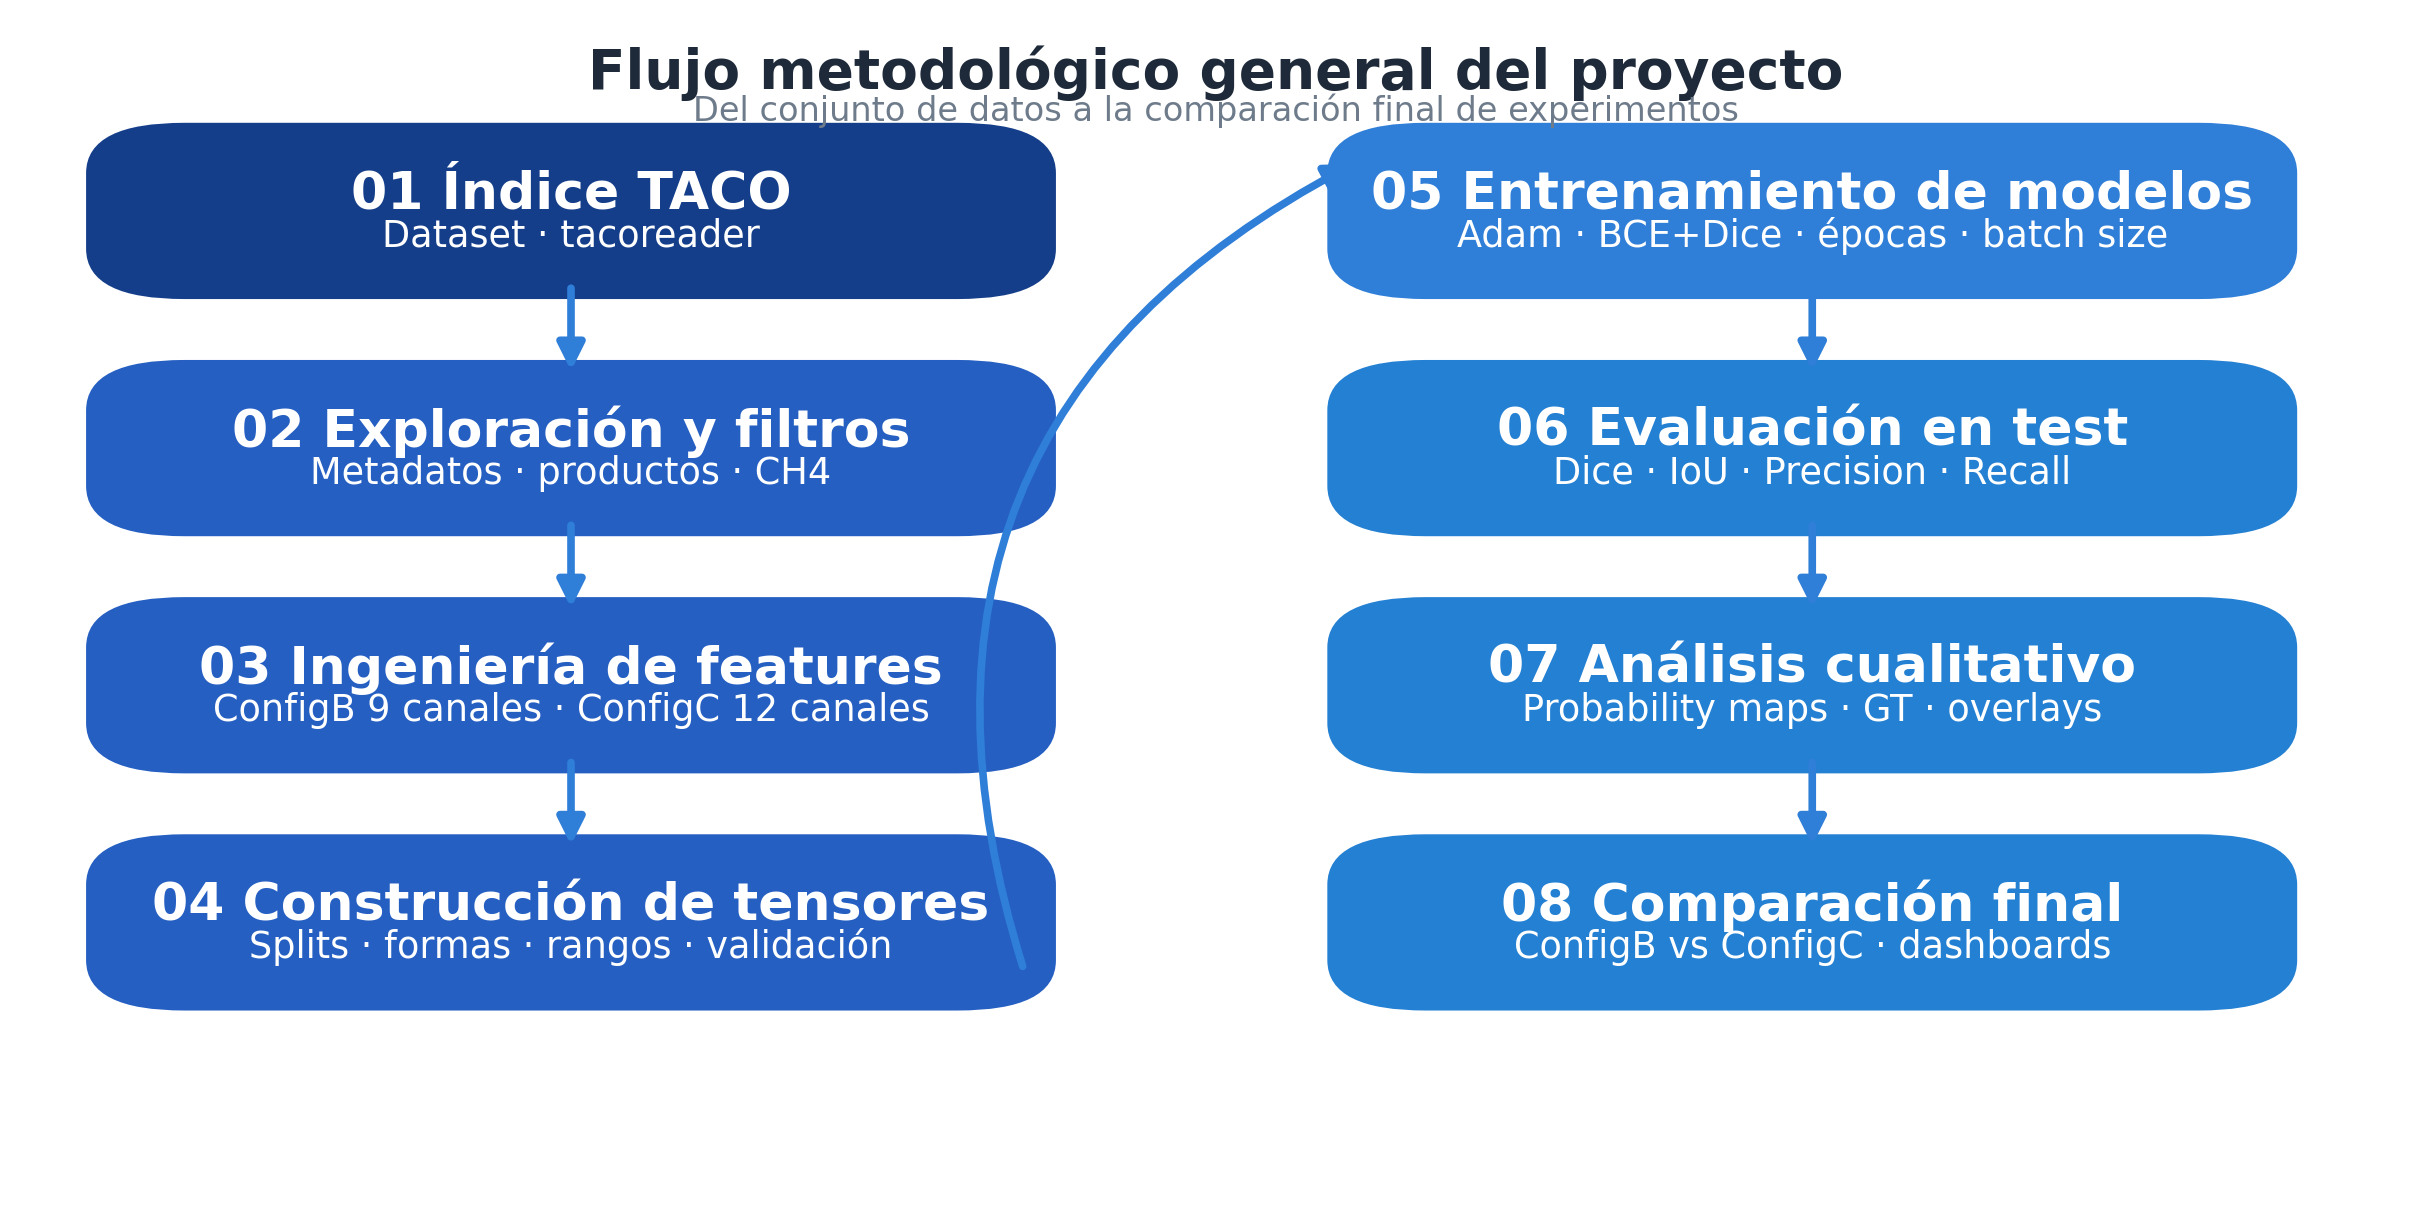

In [3]:
def figure_methodology_pipeline():
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    add_title(ax, "Flujo metodológico general del proyecto",
              "Del conjunto de datos a la comparación final de experimentos")

    left_x = 0.04
    right_x = 0.56
    box_w = 0.38
    box_h = 0.12

    ys_left = [0.78, 0.58, 0.38, 0.18]
    ys_right = [0.78, 0.58, 0.38, 0.18]

    left_boxes = [
        ("01 Índice TACO", "Dataset · tacoreader"),
        ("02 Exploración y filtros", "Metadatos · productos · CH4"),
        ("03 Ingeniería de features", "ConfigB 9 canales · ConfigC 12 canales"),
        ("04 Construcción de tensores", "Splits · formas · rangos · validación"),
    ]

    right_boxes = [
        ("05 Entrenamiento de modelos", "Adam · BCE+Dice · épocas · batch size"),
        ("06 Evaluación en test", "Dice · IoU · Precision · Recall"),
        ("07 Análisis cualitativo", "Probability maps · GT · overlays"),
        ("08 Comparación final", "ConfigB vs ConfigC · dashboards"),
    ]

    for y, (t1, t2) in zip(ys_left, left_boxes):
        add_round_box(ax, (left_x, y), box_w, box_h, t1,
                      fc=NAVY if y > 0.60 else "#255FC2",
                      subtitle=t2, fontsize=17, subtitle_size=12)

    for y, (t1, t2) in zip(ys_right, right_boxes):
        add_round_box(ax, (right_x, y), box_w, box_h, t1,
                      fc=BLUE if y > 0.60 else "#2480D2",
                      subtitle=t2, fontsize=17, subtitle_size=12)

    for i in range(len(ys_left)-1):
        add_arrow(ax, (left_x + box_w/2, ys_left[i]),
                  (left_x + box_w/2, ys_left[i+1] + box_h),
                  color=BLUE)

    for i in range(len(ys_right)-1):
        add_arrow(ax, (right_x + box_w/2, ys_right[i]),
                  (right_x + box_w/2, ys_right[i+1] + box_h),
                  color=BLUE)

    add_arrow(ax, (left_x + box_w, ys_left[-1] + box_h*0.15),
              (right_x, ys_right[0] + box_h*0.85),
              color=BLUE, rad=-0.42)

    return save_figure(fig, "Figure_Methodology_Pipeline")

path = figure_methodology_pipeline()
show_saved(path)

## Figura 2. Estructura del proyecto

Representa la organización lógica del repositorio: configuraciones, código fuente, scripts y salidas experimentales.


[OK] Guardado: /data/users/kabasmen/MethaneProjectTFM/Docs/MethodologyFig/Figure_ProjectStructure.png


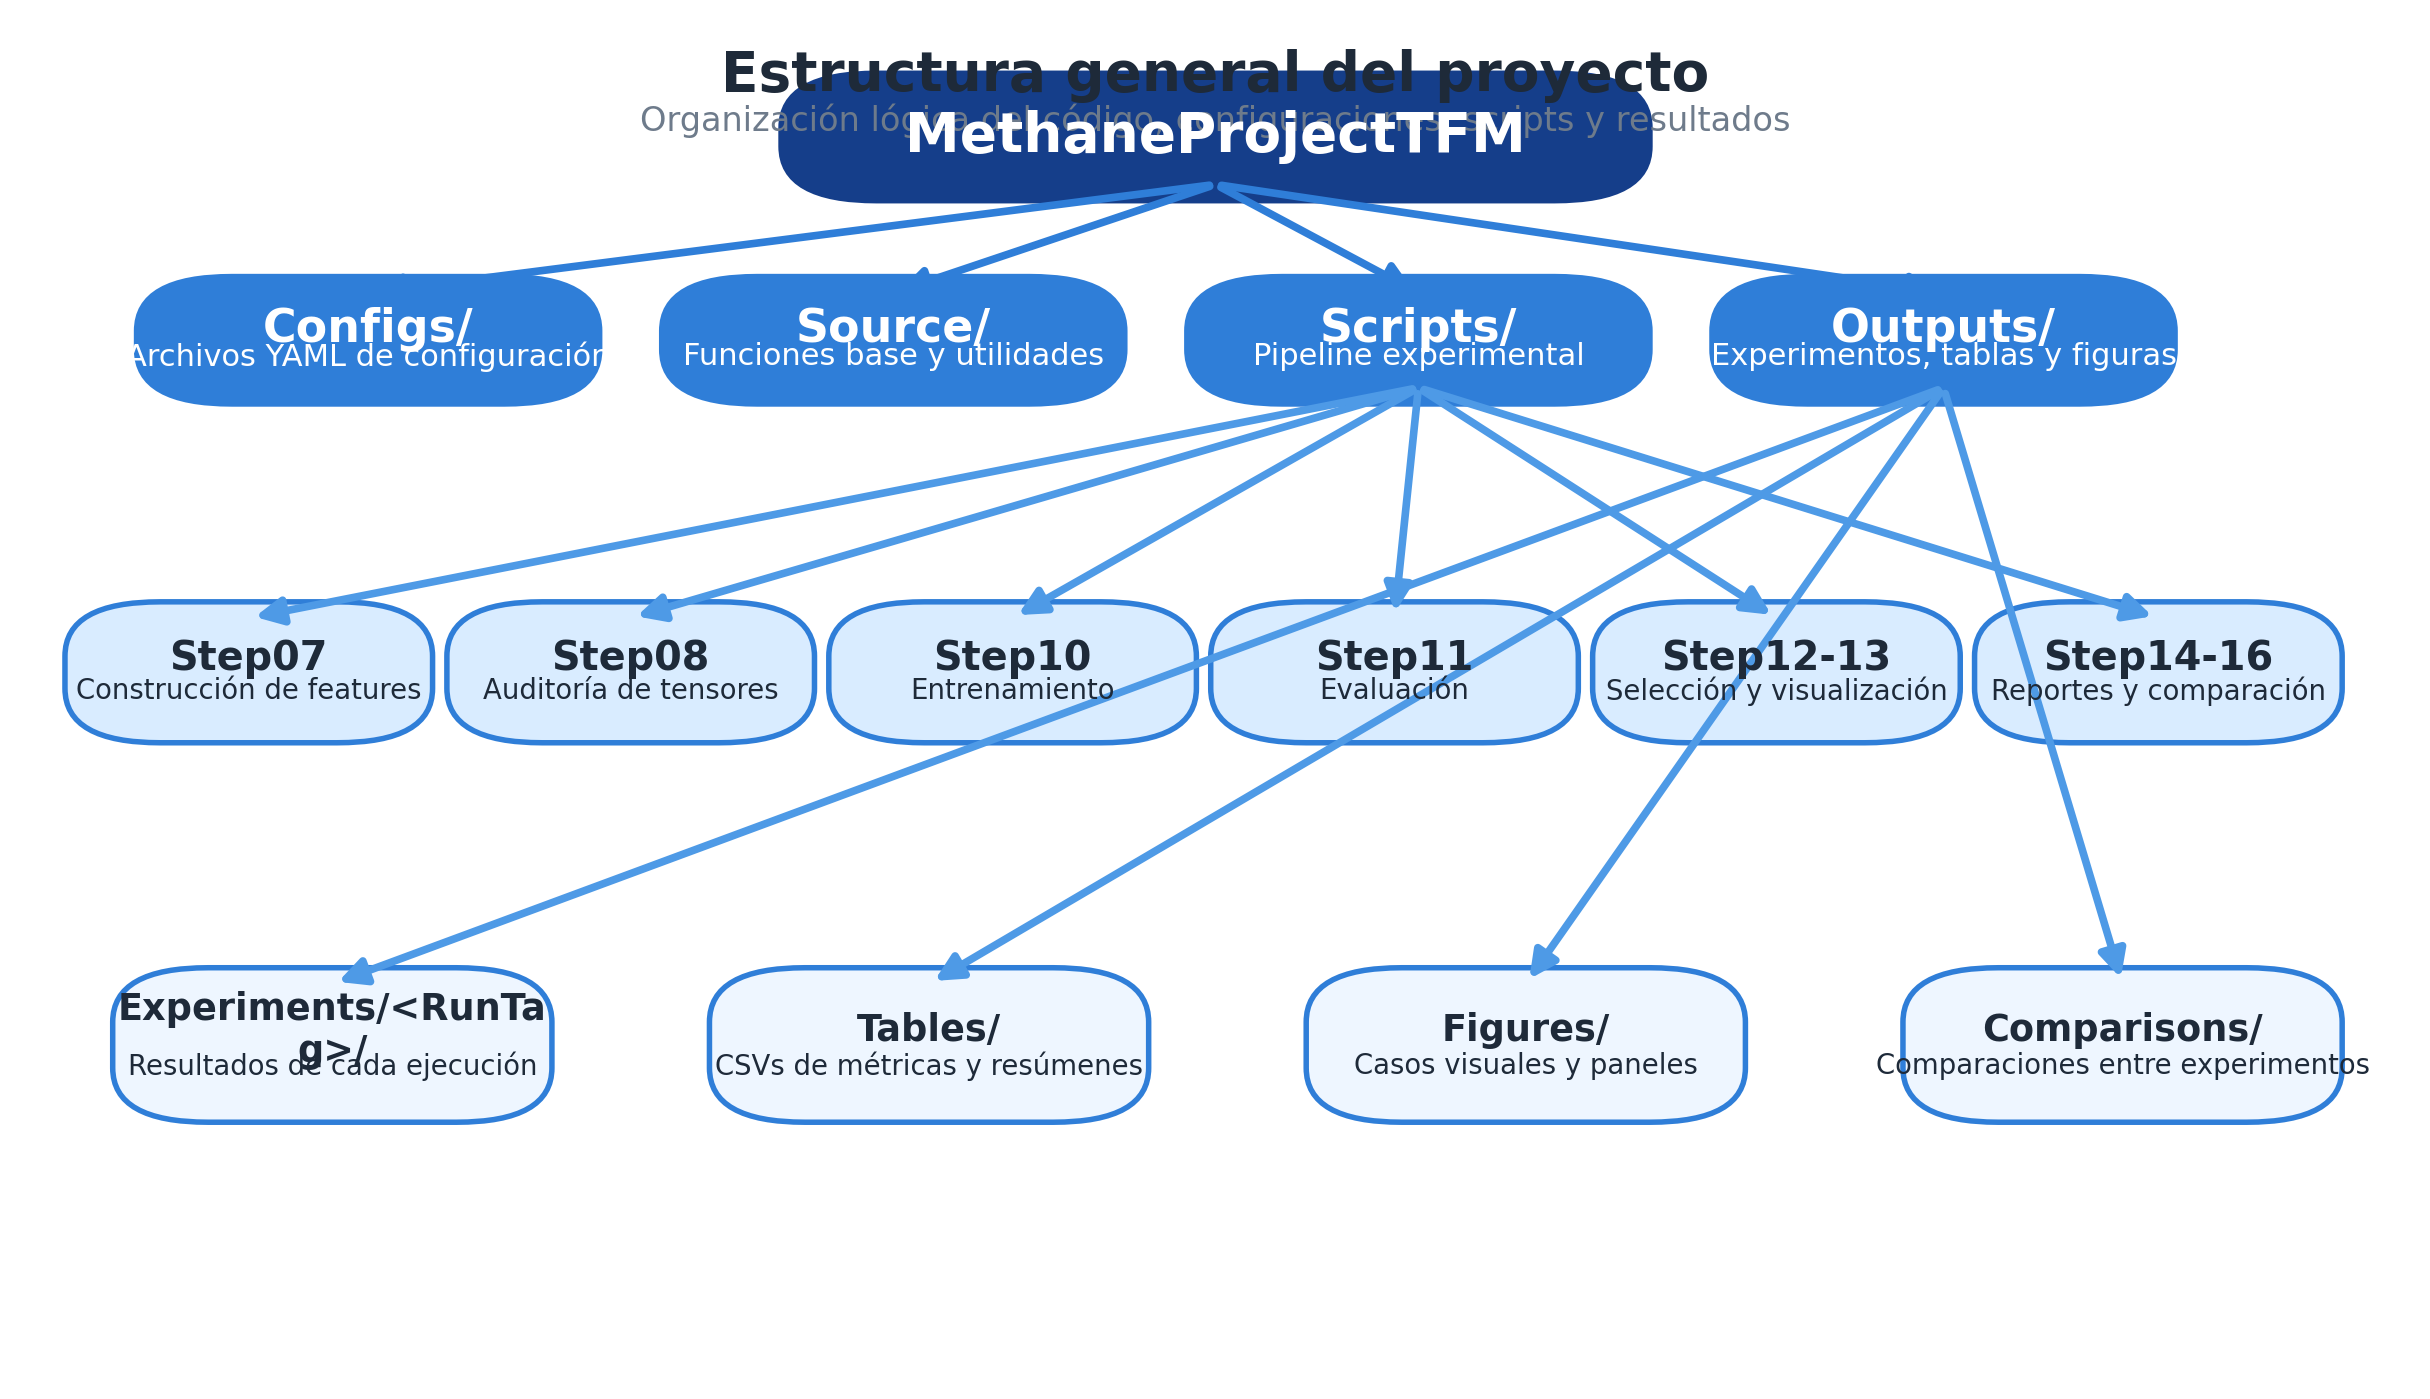

In [4]:
def figure_project_structure():
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    add_title(ax, "Estructura general del proyecto",
              "Organización lógica del código, configuraciones, scripts y resultados")

    add_round_box(ax, (0.33, 0.88), 0.34, 0.07,
                  "MethaneProjectTFM",
                  fc=NAVY, fontsize=18)

    root_x = 0.50
    child_y = 0.73
    child_w = 0.17
    child_h = 0.07

    xs = [0.06, 0.28, 0.50, 0.72]
    names = [
        ("Configs/", "Archivos YAML de configuración"),
        ("Source/", "Funciones base y utilidades"),
        ("Scripts/", "Pipeline experimental"),
        ("Outputs/", "Experimentos, tablas y figuras"),
    ]

    for x, (name, sub) in zip(xs, names):
        add_round_box(ax, (x, child_y), child_w, child_h, name,
                      fc=BLUE, subtitle=sub, fontsize=15, subtitle_size=10)
        add_arrow(ax, (root_x, 0.88), (x + child_w/2, child_y + child_h), color=BLUE)

    script_y = 0.48
    script_items = [
        ("Step07", "Construcción de features"),
        ("Step08", "Auditoría de tensores"),
        ("Step10", "Entrenamiento"),
        ("Step11", "Evaluación"),
        ("Step12-13", "Selección y visualización"),
        ("Step14-16", "Reportes y comparación"),
    ]
    script_xs = [0.03, 0.19, 0.35, 0.51, 0.67, 0.83]
    for x, (t1, t2) in zip(script_xs, script_items):
        add_round_box(ax, (x, script_y), 0.13, 0.08, t1,
                      fc=LIGHT_BLUE, ec=BLUE, text_color=DARK,
                      subtitle=t2, subtitle_size=9, fontsize=13)
        add_arrow(ax, (0.585, child_y), (x + 0.065, script_y + 0.08), color=MID_BLUE)

    out_y = 0.20
    out_items = [
        ("Experiments/<RunTag>/", "Resultados de cada ejecución"),
        ("Tables/", "CSVs de métricas y resúmenes"),
        ("Figures/", "Casos visuales y paneles"),
        ("Comparisons/", "Comparaciones entre experimentos"),
    ]
    out_xs = [0.05, 0.30, 0.55, 0.80]
    for x, (t1, t2) in zip(out_xs, out_items):
        add_round_box(ax, (x, out_y), 0.16, 0.09, wrap(t1, 18),
                      fc=PALE_BLUE, ec=BLUE, text_color=DARK,
                      subtitle=t2, subtitle_size=9, fontsize=12)
        add_arrow(ax, (0.805, child_y), (x + 0.08, out_y + 0.09), color=MID_BLUE)

    return save_figure(fig, "Figure_ProjectStructure")

path = figure_project_structure()
show_saved(path)

## Figura 3. ConfigB y ConfigC

Resume la composición de canales de las dos configuraciones principales.


[OK] Guardado: /data/users/kabasmen/MethaneProjectTFM/Docs/MethodologyFig/Figure_ConfigB_ConfigC_Channels.png


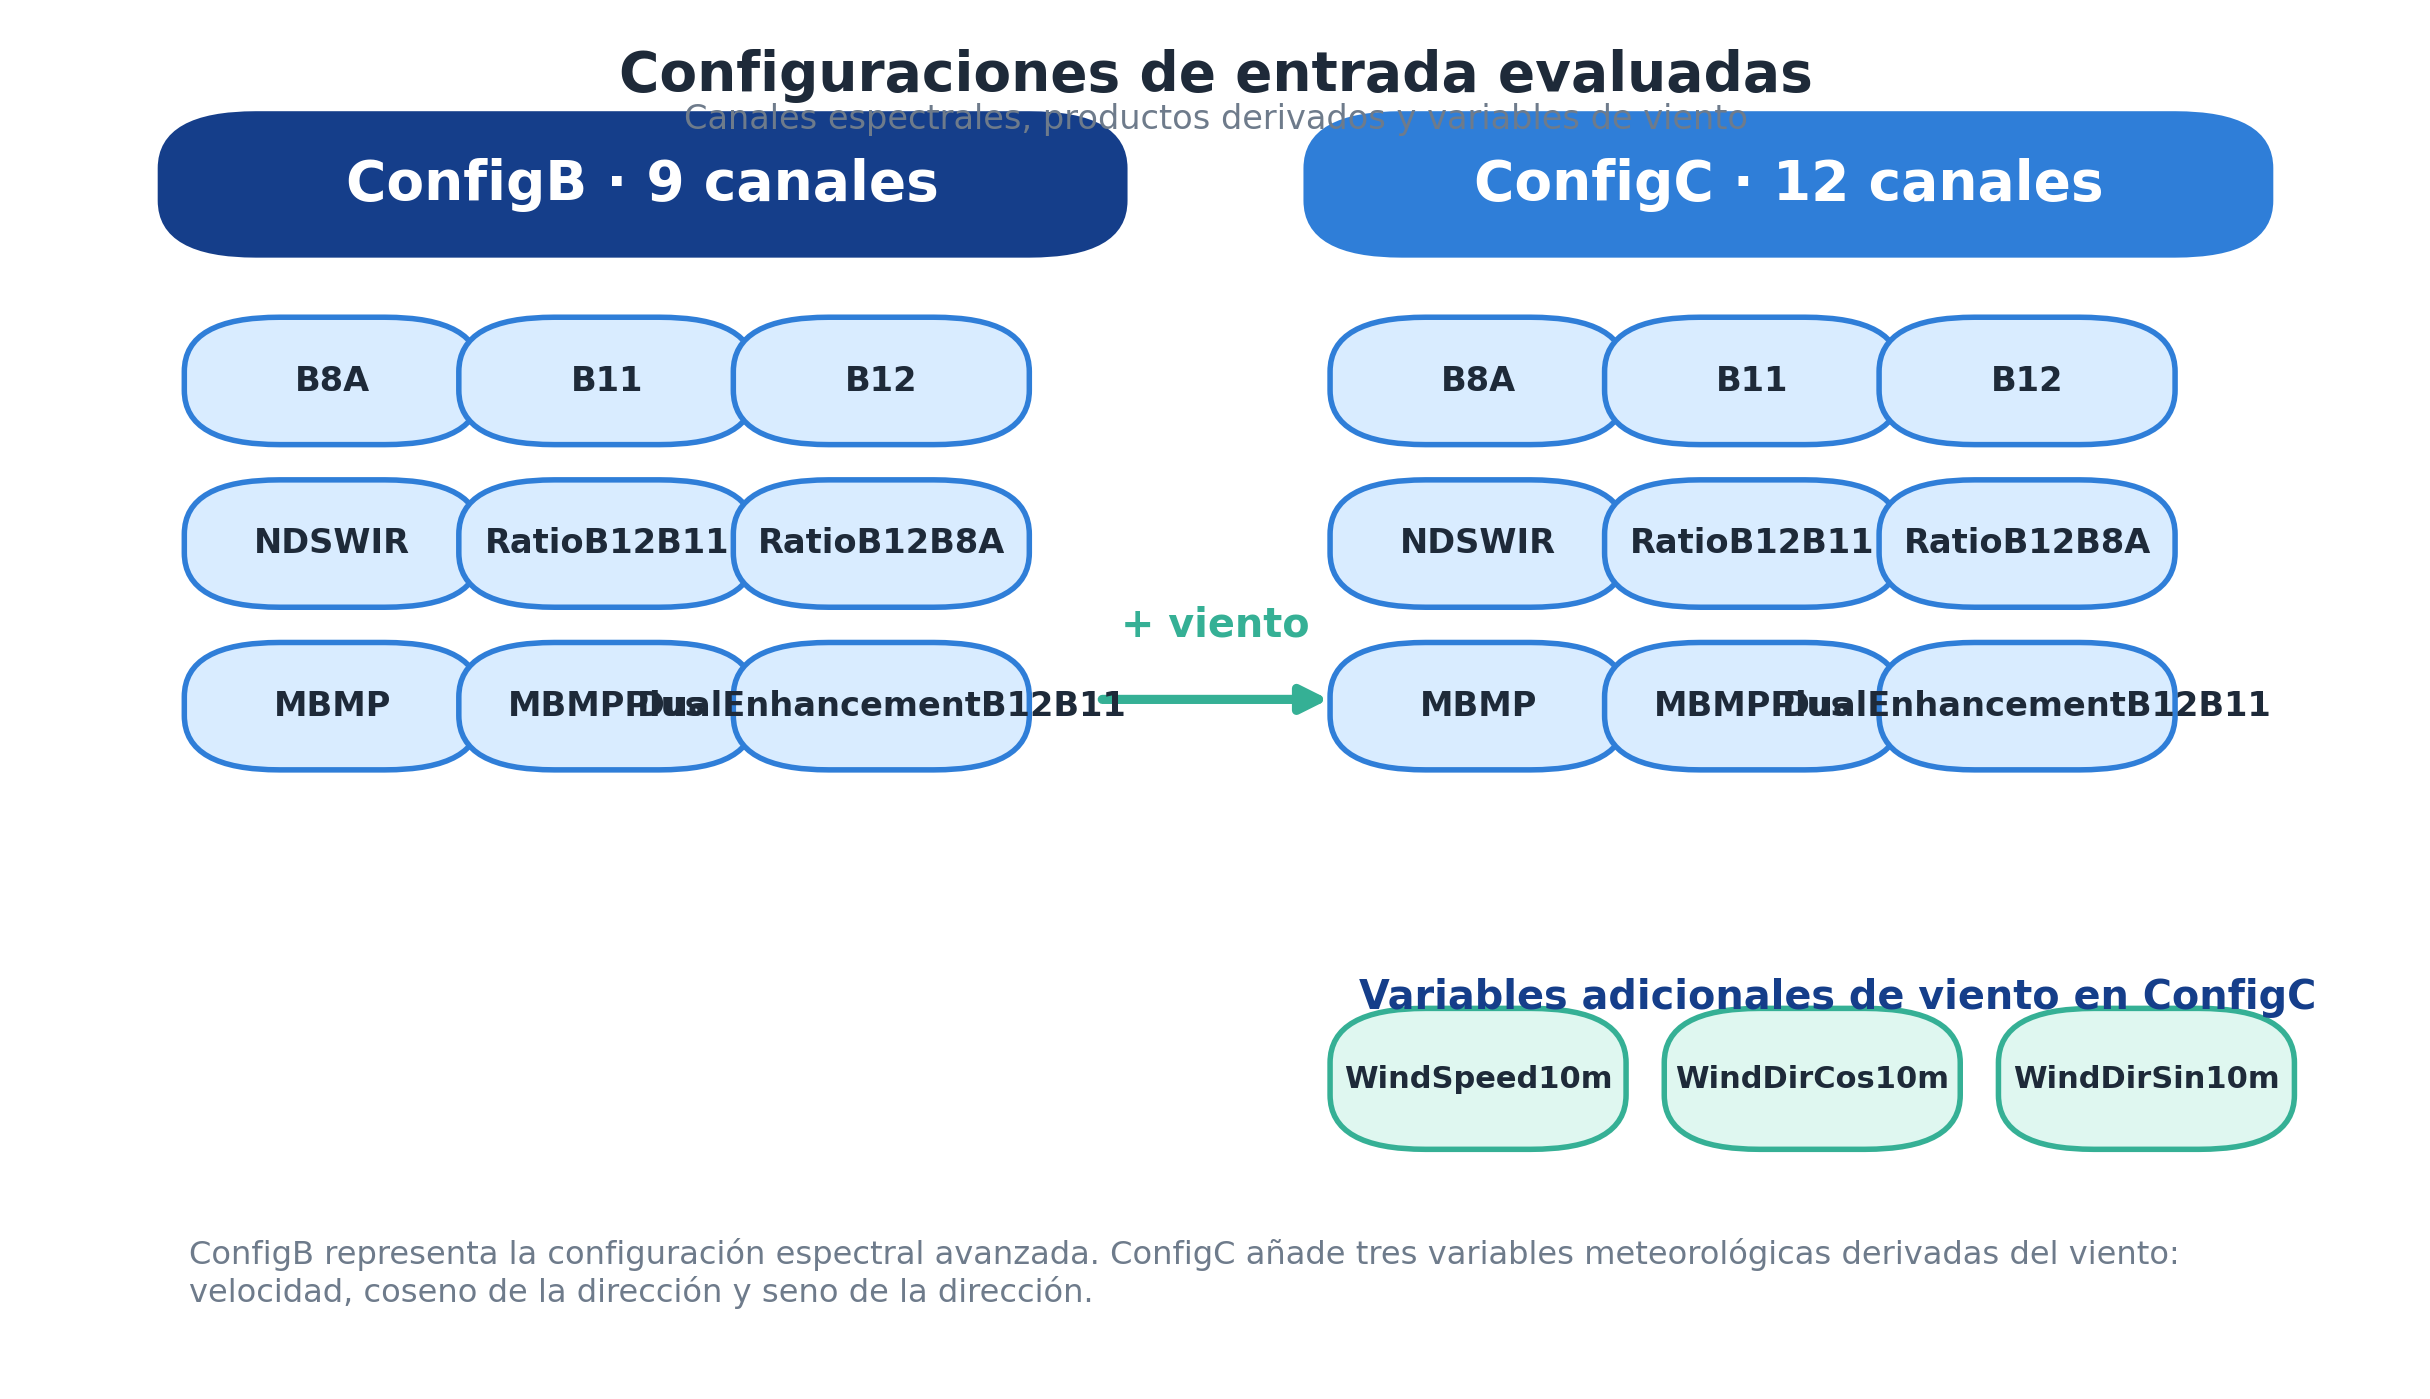

In [5]:
def figure_config_channels():
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    add_title(ax, "Configuraciones de entrada evaluadas",
              "Canales espectrales, productos derivados y variables de viento")

    add_round_box(ax, (0.07, 0.84), 0.38, 0.08, "ConfigB · 9 canales",
                  fc=NAVY, fontsize=18)

    channels_b = [
        "B8A", "B11", "B12",
        "NDSWIR", "RatioB12B11", "RatioB12B8A",
        "MBMP", "MBMPPlus", "DualEnhancementB12B11"
    ]

    add_round_box(ax, (0.55, 0.84), 0.38, 0.08, "ConfigC · 12 canales",
                  fc=BLUE, fontsize=18)

    wind_channels = ["WindSpeed10m", "WindDirCos10m", "WindDirSin10m"]

    x0, y0 = 0.08, 0.70
    dx, dy = 0.115, 0.12
    for i, ch in enumerate(channels_b):
        col = i % 3
        row = i // 3
        add_round_box(ax, (x0 + col*dx, y0 - row*dy), 0.10, 0.07, ch,
                      fc=LIGHT_BLUE, ec=BLUE, text_color=DARK,
                      fontsize=11, weight="bold")

    x1, y1 = 0.56, 0.70
    for i, ch in enumerate(channels_b):
        col = i % 3
        row = i // 3
        add_round_box(ax, (x1 + col*dx, y1 - row*dy), 0.10, 0.07, ch,
                      fc=LIGHT_BLUE, ec=BLUE, text_color=DARK,
                      fontsize=11, weight="bold")

    add_section_label(ax, 0.56, 0.28, "Variables adicionales de viento en ConfigC")
    wx = [0.56, 0.70, 0.84]
    for x, ch in zip(wx, wind_channels):
        add_round_box(ax, (x, 0.18), 0.10, 0.08, wrap(ch, 14),
                      fc="#DFF7F0", ec=GREEN, text_color=DARK,
                      fontsize=10, weight="bold")

    add_arrow(ax, (0.45, 0.50), (0.55, 0.50), color=GREEN, lw=3.0)
    ax.text(0.50, 0.54, "+ viento", ha="center", va="bottom",
            fontsize=13, color=GREEN, fontweight="bold")

    note = (
        "ConfigB representa la configuración espectral avanzada. "
        "ConfigC añade tres variables meteorológicas derivadas del viento: velocidad, "
        "coseno de la dirección y seno de la dirección."
    )
    ax.text(0.07, 0.05, wrap(note, 130), ha="left", va="bottom",
            fontsize=10.5, color=GRAY)

    return save_figure(fig, "Figure_ConfigB_ConfigC_Channels")

path = figure_config_channels()
show_saved(path)

## Figura 4. Familias de modelos evaluadas

Presenta la lógica de comparación entre arquitecturas: SimpleUNet, EnhancedUNet, TransformerUNet y TransformerPlus.


[OK] Guardado: /data/users/kabasmen/MethaneProjectTFM/Docs/MethodologyFig/Figure_ModelFamilies.png


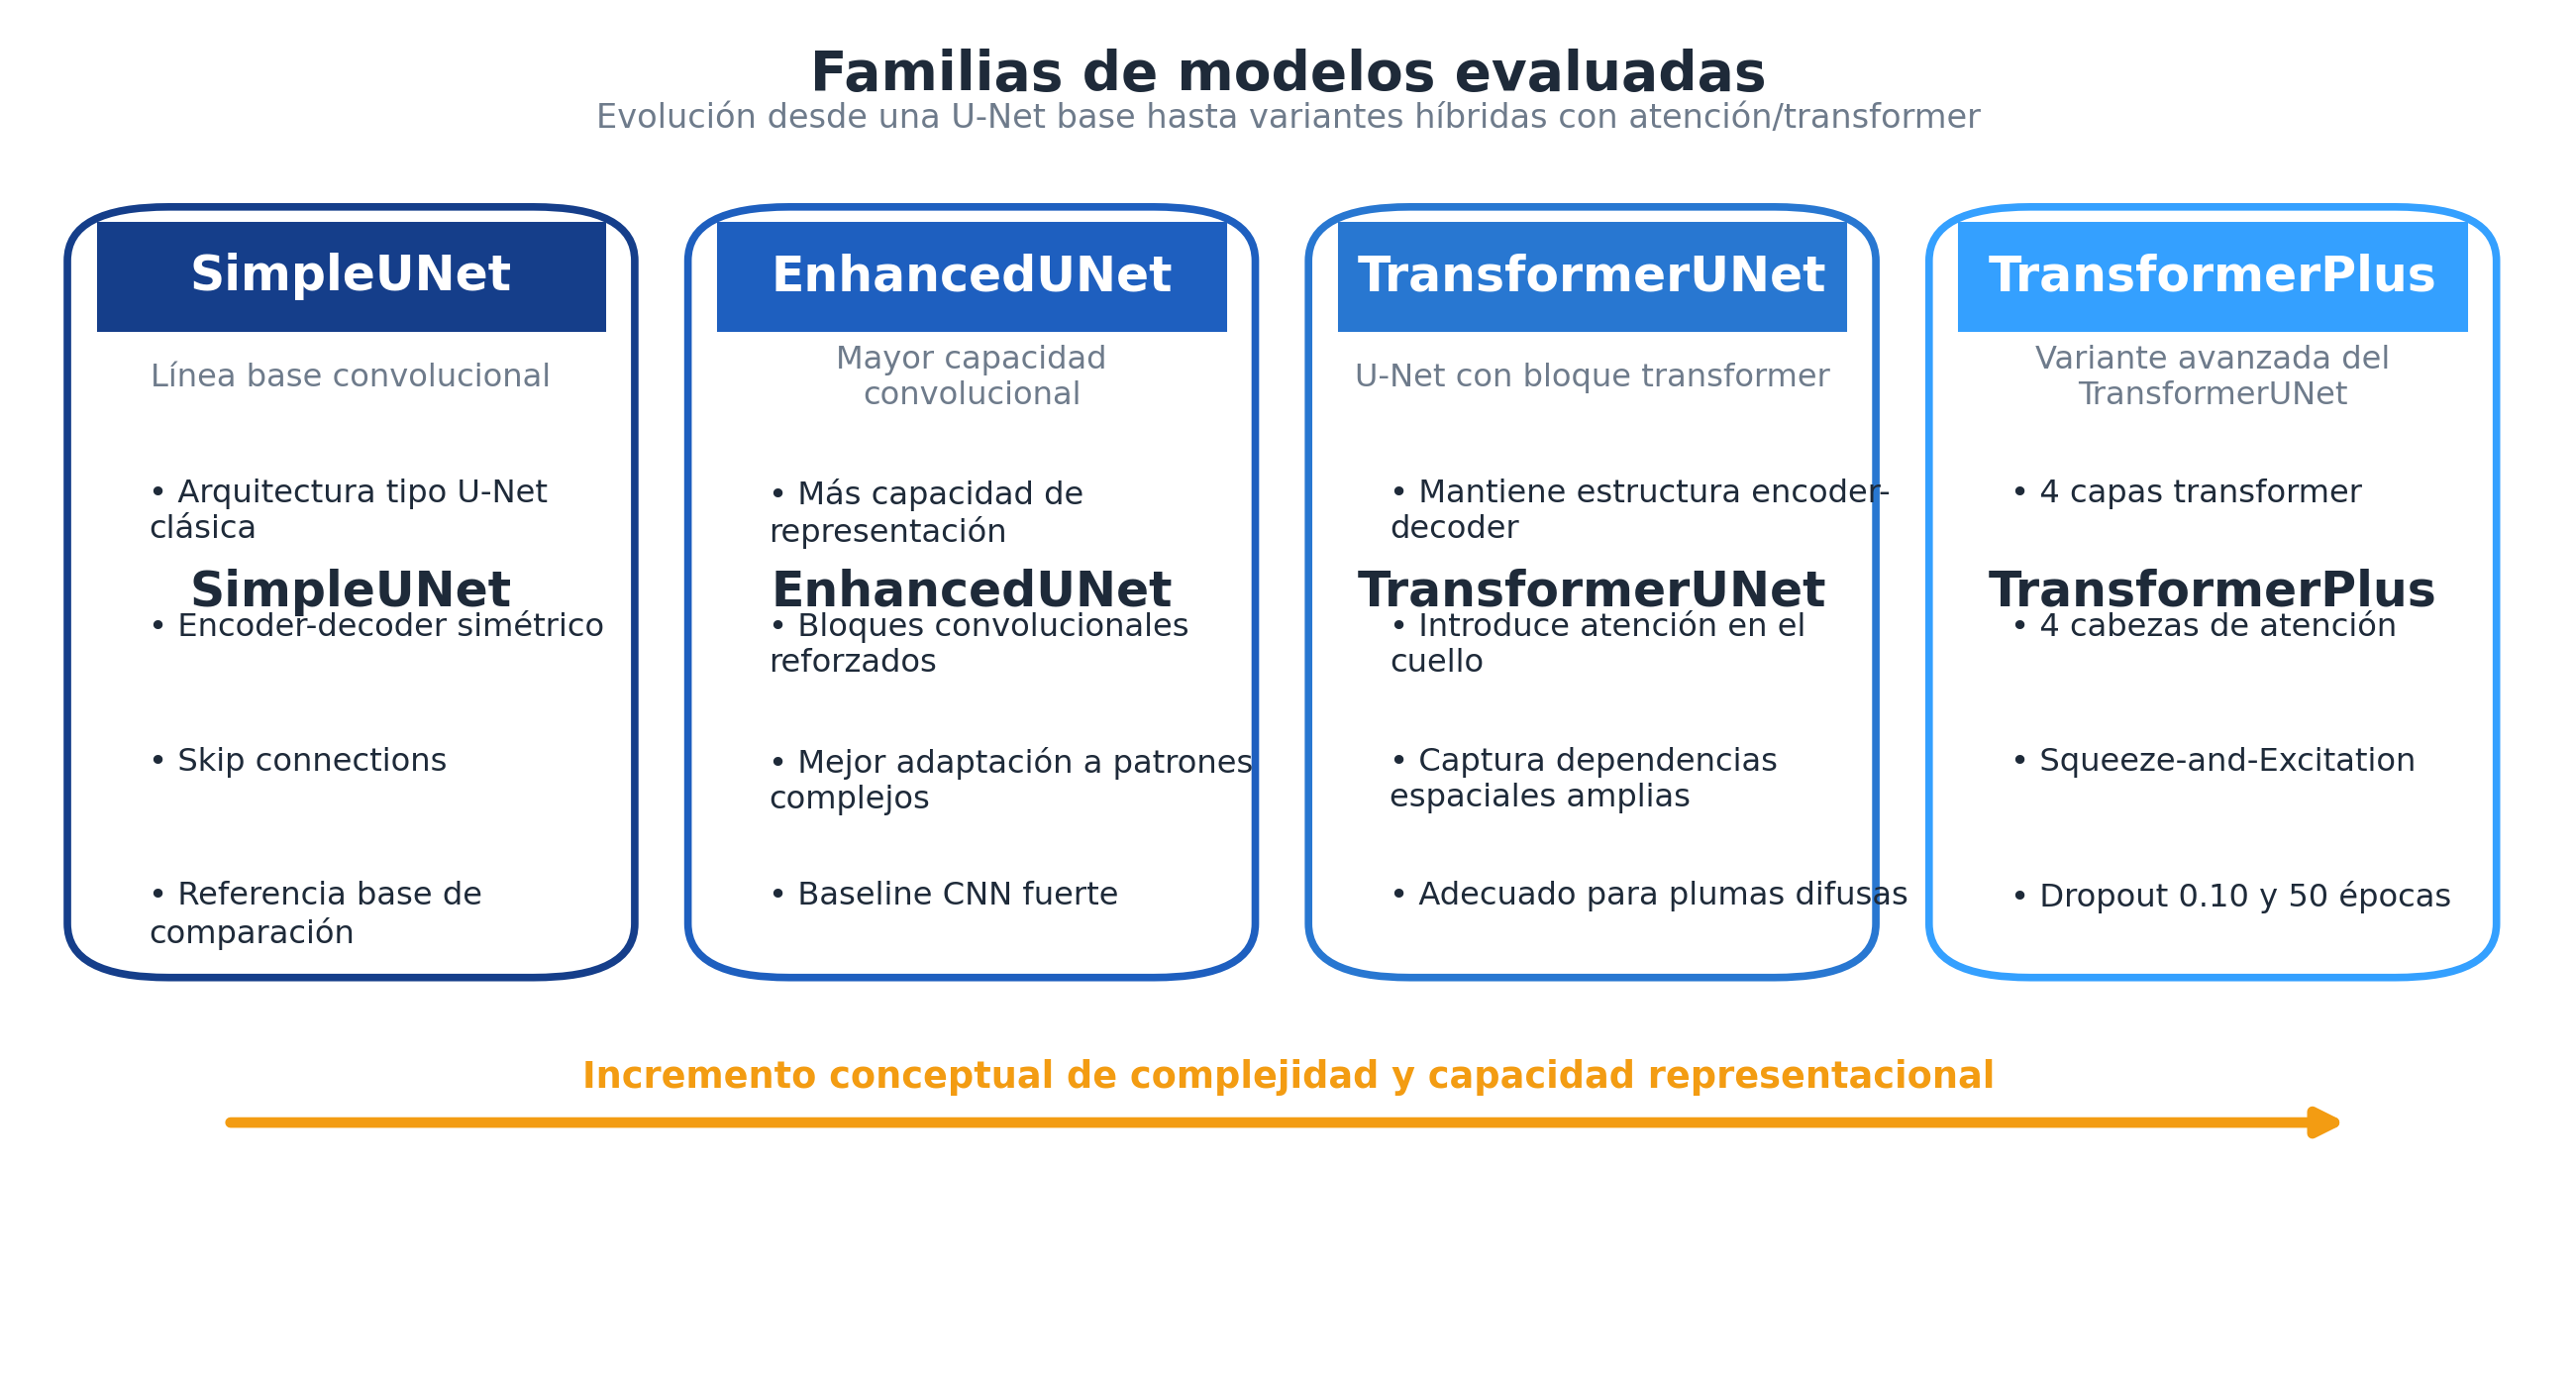

In [6]:
def figure_model_families():
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    add_title(ax, "Familias de modelos evaluadas",
              "Evolución desde una U-Net base hasta variantes híbridas con atención/transformer")

    card_w, card_h = 0.20, 0.55
    xs = [0.03, 0.275, 0.52, 0.765]
    titles = ["SimpleUNet", "EnhancedUNet", "TransformerUNet", "TransformerPlus"]
    subtitles = [
        "Línea base convolucional",
        "Mayor capacidad convolucional",
        "U-Net con bloque transformer",
        "Variante avanzada del TransformerUNet"
    ]
    bullets = [
        [
            "Arquitectura tipo U-Net clásica",
            "Encoder-decoder simétrico",
            "Skip connections",
            "Referencia base de comparación"
        ],
        [
            "Más capacidad de representación",
            "Bloques convolucionales reforzados",
            "Mejor adaptación a patrones complejos",
            "Baseline CNN fuerte"
        ],
        [
            "Mantiene estructura encoder-decoder",
            "Introduce atención en el cuello",
            "Captura dependencias espaciales amplias",
            "Adecuado para plumas difusas"
        ],
        [
            "4 capas transformer",
            "4 cabezas de atención",
            "Squeeze-and-Excitation",
            "Dropout 0.10 y 50 épocas"
        ],
    ]
    colors = [NAVY, "#1E5FBF", "#2877D1", "#34A0FF"]

    for x, title, sub, blt, c in zip(xs, titles, subtitles, bullets, colors):
        add_round_box(ax, (x, 0.30), card_w, card_h, title,
                      fc=WHITE, ec=c, text_color=DARK,
                      fontsize=16, weight="bold", lw=2.5)
        ax.add_patch(Rectangle((x, 0.77), card_w, 0.08, color=c, ec=c))
        ax.text(x + card_w/2, 0.81, title, ha="center", va="center",
                fontsize=16, color=WHITE, fontweight="bold")
        ax.text(x + card_w/2, 0.735, wrap(sub, 28), ha="center", va="center",
                fontsize=10.5, color=GRAY)

        yy = 0.66
        for item in blt:
            ax.text(x + 0.02, yy, u"\u2022 " + wrap(item, 28),
                    ha="left", va="top", fontsize=10.5, color=DARK)
            yy -= 0.10

    add_arrow(ax, (0.08, 0.18), (0.92, 0.18), color=ORANGE, lw=3.5)
    ax.text(0.50, 0.20, "Incremento conceptual de complejidad y capacidad representacional",
            ha="center", va="bottom", fontsize=12, color=ORANGE, fontweight="bold")

    return save_figure(fig, "Figure_ModelFamilies")

path = figure_model_families()
show_saved(path)

## Figura 5. Flujo de evaluación

Resume el paso desde el mapa de probabilidad hasta las métricas y el overlay TP/FP/FN.


[OK] Guardado: /data/users/kabasmen/MethaneProjectTFM/Docs/MethodologyFig/Figure_EvaluationWorkflow.png


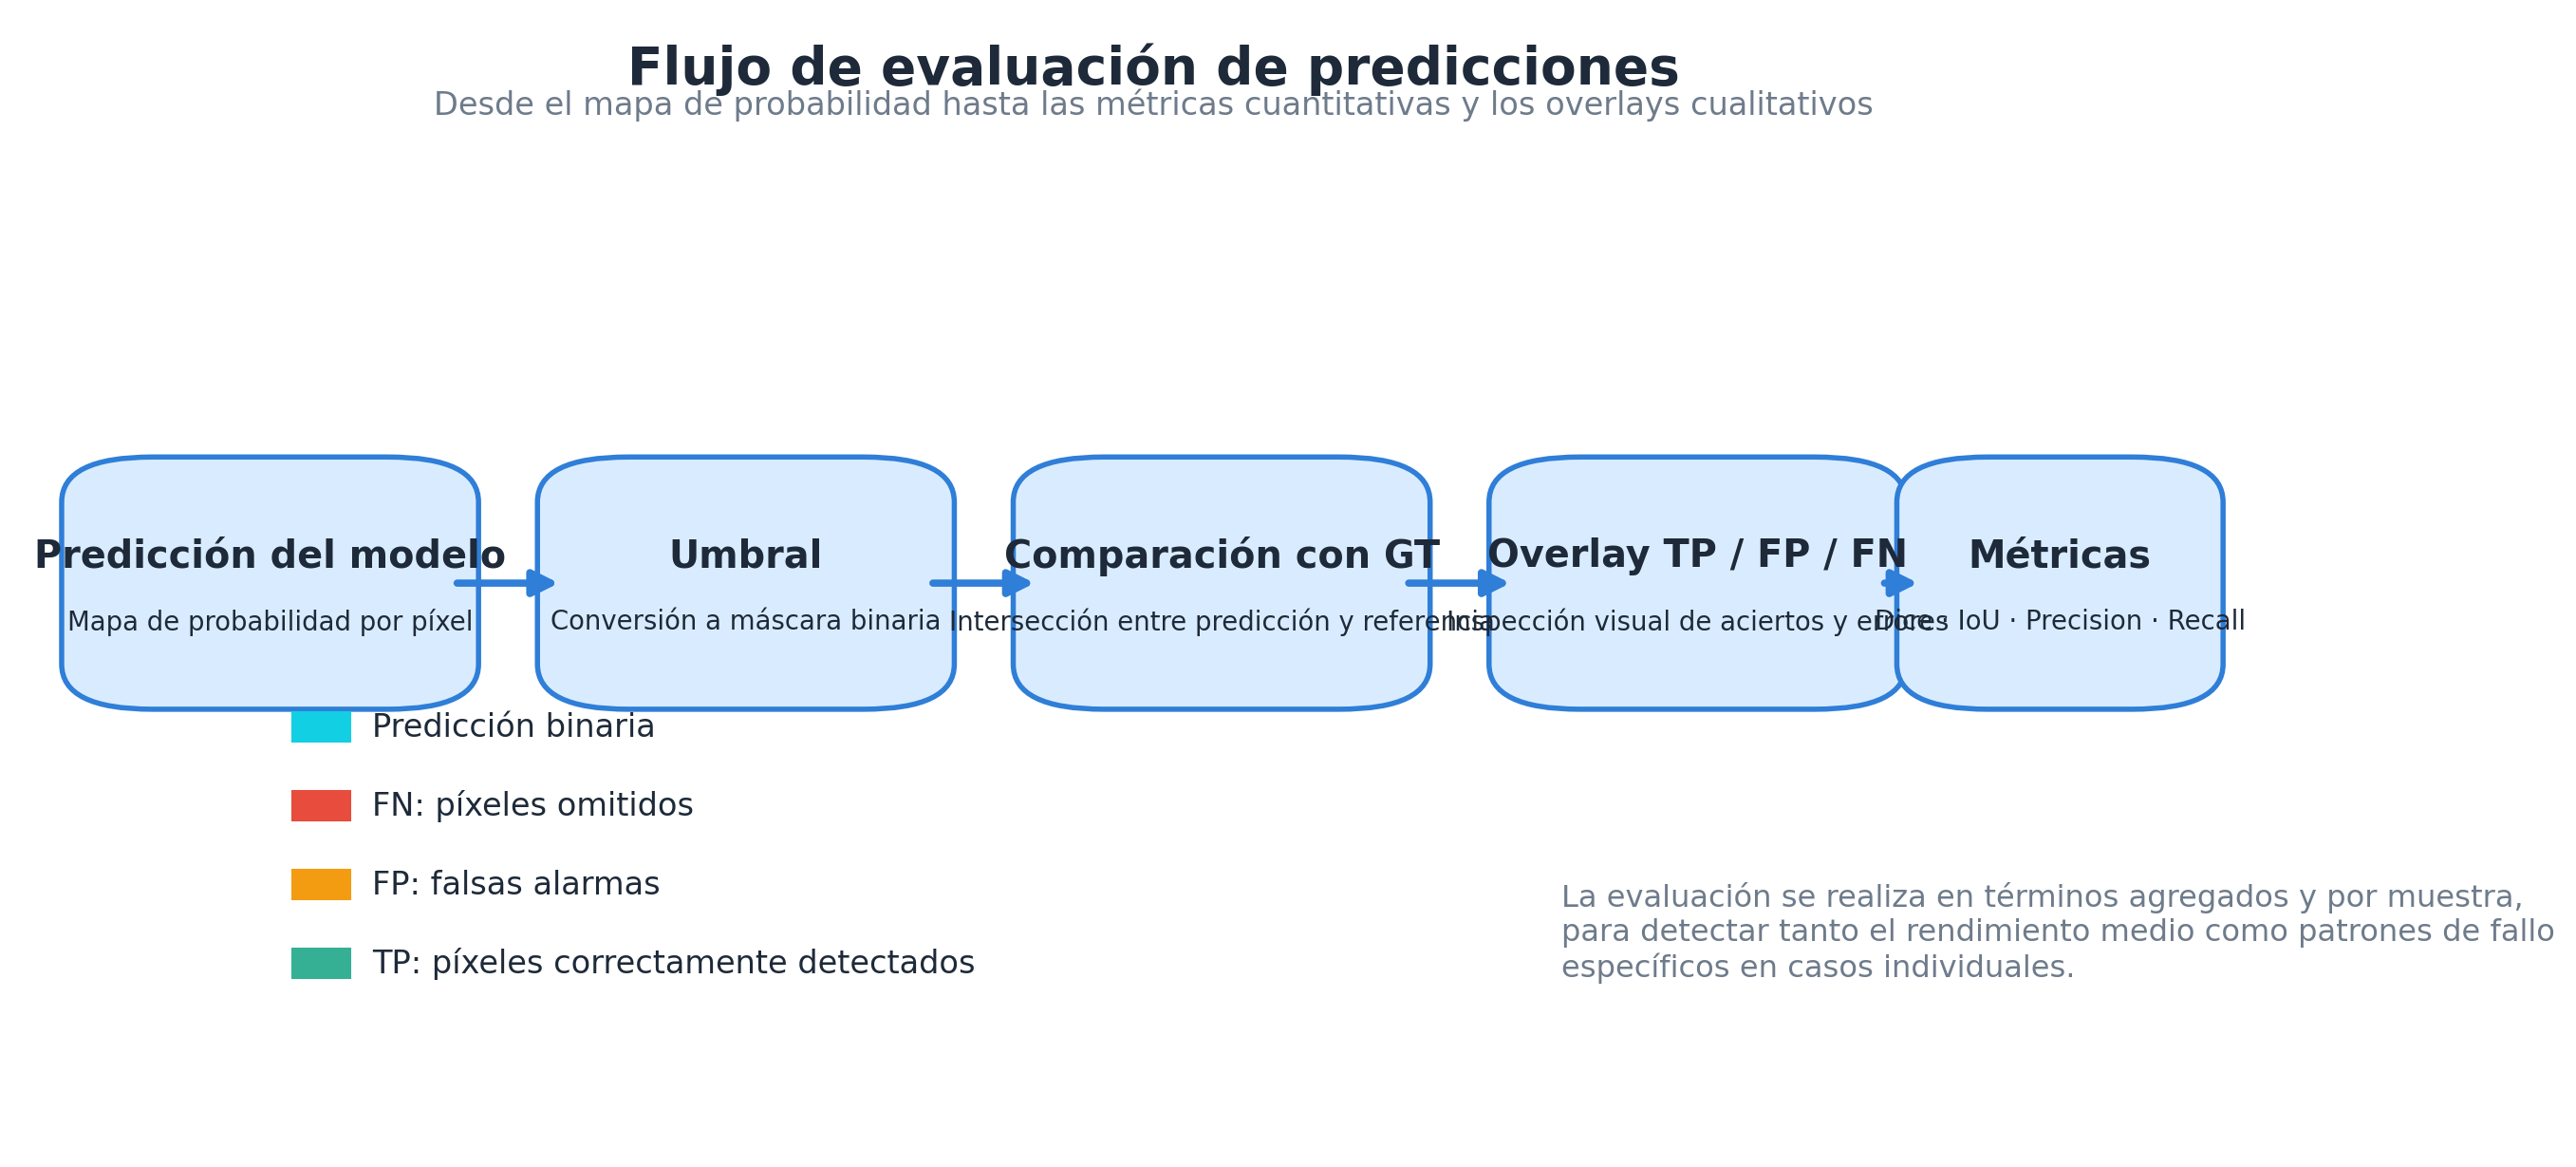

In [7]:
def figure_evaluation_workflow():
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    add_title(ax, "Flujo de evaluación de predicciones",
              "Desde el mapa de probabilidad hasta las métricas cuantitativas y los overlays cualitativos")

    items = [
        ("Predicción del modelo", "Mapa de probabilidad por píxel"),
        ("Umbral", "Conversión a máscara binaria"),
        ("Comparación con GT", "Intersección entre predicción y referencia"),
        ("Overlay TP / FP / FN", "Inspección visual de aciertos y errores"),
        ("Métricas", "Dice · IoU · Precision · Recall"),
    ]

    xs = [0.03, 0.24, 0.45, 0.66, 0.84]
    widths = [0.16, 0.16, 0.16, 0.16, 0.12]
    for x, w, (t1, t2) in zip(xs, widths, items):
        add_round_box(ax, (x, 0.40), w, 0.20, t1,
                      fc=LIGHT_BLUE, ec=BLUE, text_color=DARK,
                      fontsize=13, subtitle=t2, subtitle_size=9)
    for i in range(len(xs)-1):
        add_arrow(ax, (xs[i] + widths[i], 0.50), (xs[i+1], 0.50), color=BLUE)

    legend_y = 0.15
    sw = 0.025
    legend = [
        (GREEN, "TP: píxeles correctamente detectados"),
        (ORANGE, "FP: falsas alarmas"),
        (RED, "FN: píxeles omitidos"),
        (CYAN, "Predicción binaria"),
    ]
    lx = 0.12
    for color, label in legend:
        ax.add_patch(Rectangle((lx, legend_y), sw, sw, facecolor=color, edgecolor=color))
        ax.text(lx + sw + 0.01, legend_y + sw/2, label, va="center", ha="left",
                fontsize=11, color=DARK)
        legend_y += 0.07

    ax.text(0.68, 0.19,
            "La evaluación se realiza en términos agregados y por muestra,\n"
            "para detectar tanto el rendimiento medio como patrones de fallo\n"
            "específicos en casos individuales.",
            ha="left", va="center", fontsize=10.5, color=GRAY)

    return save_figure(fig, "Figure_EvaluationWorkflow")

path = figure_evaluation_workflow()
show_saved(path)

## Figura 6. Panel de visualización cualitativa

Esquematiza la estructura del panel 3×4 utilizado para inspeccionar visualmente las predicciones.


[OK] Guardado: /data/users/kabasmen/MethaneProjectTFM/Docs/MethodologyFig/Figure_PredictionPanelLayout.png


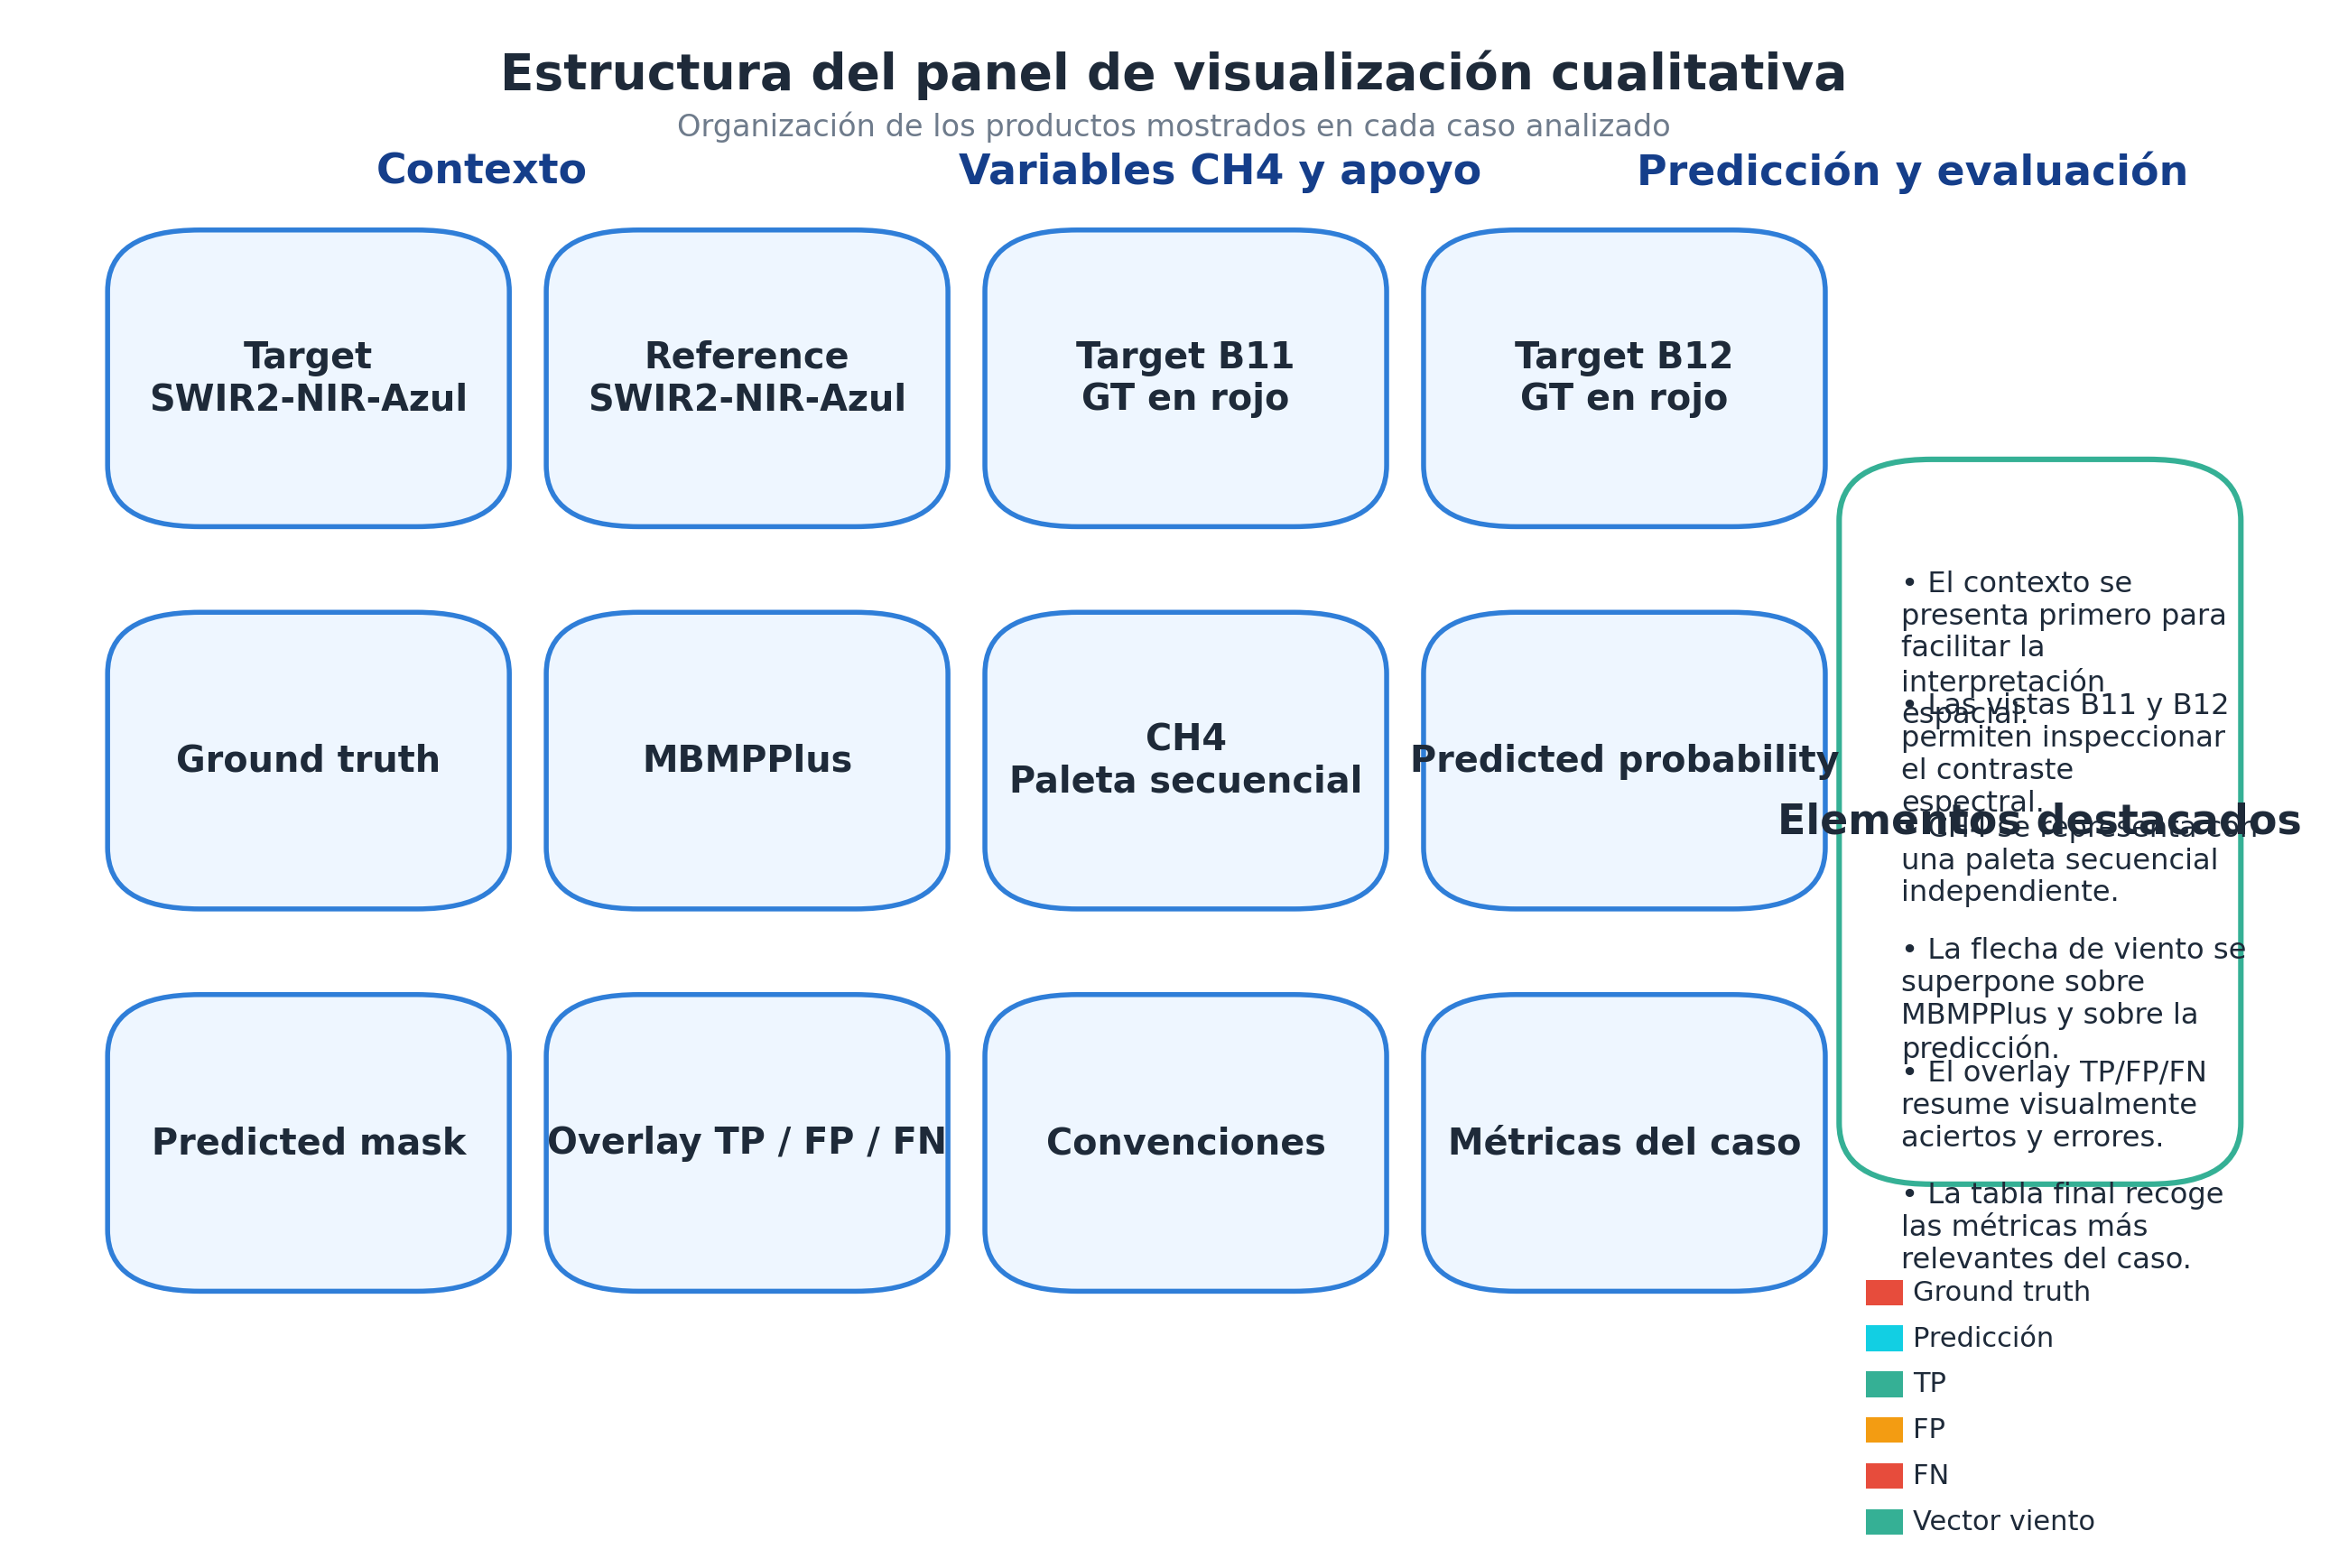

In [8]:
def figure_prediction_panel_layout():
    fig, ax = plt.subplots(figsize=(15, 10))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    add_title(ax, "Estructura del panel de visualización cualitativa",
              "Organización de los productos mostrados en cada caso analizado")

    ax.text(0.20, 0.90, "Contexto", ha="center", va="center",
            fontsize=15, fontweight="bold", color=NAVY)
    ax.text(0.52, 0.90, "Variables CH4 y apoyo", ha="center", va="center",
            fontsize=15, fontweight="bold", color=NAVY)
    ax.text(0.82, 0.90, "Predicción y evaluación", ha="center", va="center",
            fontsize=15, fontweight="bold", color=NAVY)

    boxes = [
        (0.05, 0.68, "Target\nSWIR2-NIR-Azul"),
        (0.24, 0.68, "Reference\nSWIR2-NIR-Azul"),
        (0.43, 0.68, "Target B11\nGT en rojo"),
        (0.62, 0.68, "Target B12\nGT en rojo"),
        (0.05, 0.43, "Ground truth"),
        (0.24, 0.43, "MBMPPlus"),
        (0.43, 0.43, "CH4\nPaleta secuencial"),
        (0.62, 0.43, "Predicted probability"),
        (0.05, 0.18, "Predicted mask"),
        (0.24, 0.18, "Overlay TP / FP / FN"),
        (0.43, 0.18, "Convenciones"),
        (0.62, 0.18, "Métricas del caso"),
    ]

    w, h = 0.15, 0.17
    for x, y, label in boxes:
        add_round_box(ax, (x, y), w, h, label,
                      fc=PALE_BLUE, ec=BLUE, text_color=DARK,
                      fontsize=13, weight="bold", lw=1.8)

    add_round_box(ax, (0.80, 0.25), 0.15, 0.45,
                  "Elementos destacados",
                  fc=WHITE, ec=GREEN, text_color=DARK,
                  fontsize=15, weight="bold", lw=2.0)

    bullet_texts = [
        "El contexto se presenta primero para facilitar la interpretación espacial.",
        "Las vistas B11 y B12 permiten inspeccionar el contraste espectral.",
        "CH4 se representa con una paleta secuencial independiente.",
        "La flecha de viento se superpone sobre MBMPPlus y sobre la predicción.",
        "El overlay TP/FP/FN resume visualmente aciertos y errores.",
        "La tabla final recoge las métricas más relevantes del caso."
    ]
    yy = 0.64
    for txt in bullet_texts:
        ax.text(0.815, yy, u"\u2022 " + wrap(txt, 22),
                ha="left", va="top", fontsize=10.5, color=DARK)
        yy -= 0.08

    legend_items = [
        (RED, "Ground truth"),
        (CYAN, "Predicción"),
        (GREEN, "TP"),
        (ORANGE, "FP"),
        (RED, "FN"),
        (GREEN, "Vector viento"),
    ]
    lx, ly = 0.80, 0.16
    for color, label in legend_items:
        ax.add_patch(Rectangle((lx, ly), 0.015, 0.015, facecolor=color, edgecolor=color))
        ax.text(lx + 0.02, ly + 0.0075, label, ha="left", va="center",
                fontsize=10, color=DARK)
        ly -= 0.03

    return save_figure(fig, "Figure_PredictionPanelLayout")

path = figure_prediction_panel_layout()
show_saved(path)

## Verificación final

Lista los archivos generados en la carpeta de salida.


In [ ]:
for path in sorted(OUTDIR.glob("Figure_*.png")):
    print(path)